# 📊 Exploratory Data Analysis — Bank Marketing Dataset

---

**Source:** Direct marketing campaigns (phone calls) of a Portuguese banking institution  
**Goal:** Predict whether a client will subscribe a **term deposit** → target variable `y` (`yes` / `no`)  
**Dataset:** `bank-additional-full.csv` · 41,188 records · 20 features · May 2008 – Nov 2010

| Property | Value |
|---|---|
| Instances | 41,188 |
| Features | 20 |
| Feature Types | Categorical, Integer, Float |
| Task | Binary Classification |

---

## 🌍 Key Economic / Social Features

| Feature | Description | Impact on Deposit |
|---|---|---|
| `emp.var.rate` | Employment Variation Rate (+ve = growth, −ve = job losses) | Job losses → clients avoid locking money in deposits |
| `cons.price.idx` | Consumer Price Index — measures inflation over time | High inflation → clients may prefer other investments |
| `cons.conf.idx` | Consumer Confidence Index — how optimistic people feel about the economy | Low confidence → less willingness to invest |
| `euribor3m` | 3-Month EURIBOR — interbank lending rate affecting loans & savings | Higher rate → term deposits become more attractive |
| `nr.employed` | Number of employed persons in the economy | Higher employment → stable income → more likely to invest |

---

## 📋 Dataset Features Overview

| Variable | Type | Description |
|---|---|---|
| `age` | Integer | Client age |
| `job` | Categorical | Type of job (admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown) |
| `marital` | Categorical | Marital status (divorced, married, single, unknown) |
| `education` | Categorical | Education level (basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown) |
| `default` | Binary | Has credit in default? |
| `balance` | Integer | Average yearly balance (euros) |
| `housing` | Binary | Has housing loan? |
| `loan` | Binary | Has personal loan? |
| `contact` | Categorical | Contact communication type (cellular, telephone) |
| `day_of_week` | Date | Last contact day of the week |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
sns.set_style("whitegrid")

# Import Data 

In [3]:
df = pd.read_csv("../data/bank-additional-full.csv",sep=";")

In [4]:
X = df.drop(columns=["y"])
y = df['y']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

train_df = X_train.copy()
train_df["y"] = y_train

test_df = X_test.copy()
test_df["y"] = y_test

train_df.to_csv("../data/train.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")


Train size: 32950 | Test size: 8238


### Over all idea of DataSet of Bank

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32950 entries, 25611 to 10747
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32950 non-null  object 
 2   marital         32950 non-null  object 
 3   education       32950 non-null  object 
 4   default         32950 non-null  object 
 5   housing         32950 non-null  object 
 6   loan            32950 non-null  object 
 7   contact         32950 non-null  object 
 8   month           32950 non-null  object 
 9   day_of_week     32950 non-null  object 
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  object 
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  float64
 17  cons.conf.idx   32950 non-null  

In [6]:
train_df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,no
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,yes
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,no
21806,29,admin.,single,university.degree,no,no,no,cellular,aug,wed,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
37395,26,student,single,basic.9y,no,no,no,telephone,aug,wed,...,1,999,0,nonexistent,-2.9,92.201,-31.4,0.879,5076.2,yes
25863,30,blue-collar,married,basic.4y,no,yes,no,cellular,nov,wed,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
7393,50,blue-collar,married,basic.4y,unknown,no,no,telephone,may,fri,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,no
14697,33,admin.,single,high.school,no,yes,no,cellular,jul,tue,...,5,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,no


### Statical Analysis

In [7]:
train_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719,0.080470,93.575881,-40.508489,3.618395,5166.899651
std,10.403636,258.975917,2.752326,187.951096,0.499025,1.571266,0.579209,4.628223,1.735896,72.434812
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
train_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

NO null values

# Univariate Analysis of Categorical Features

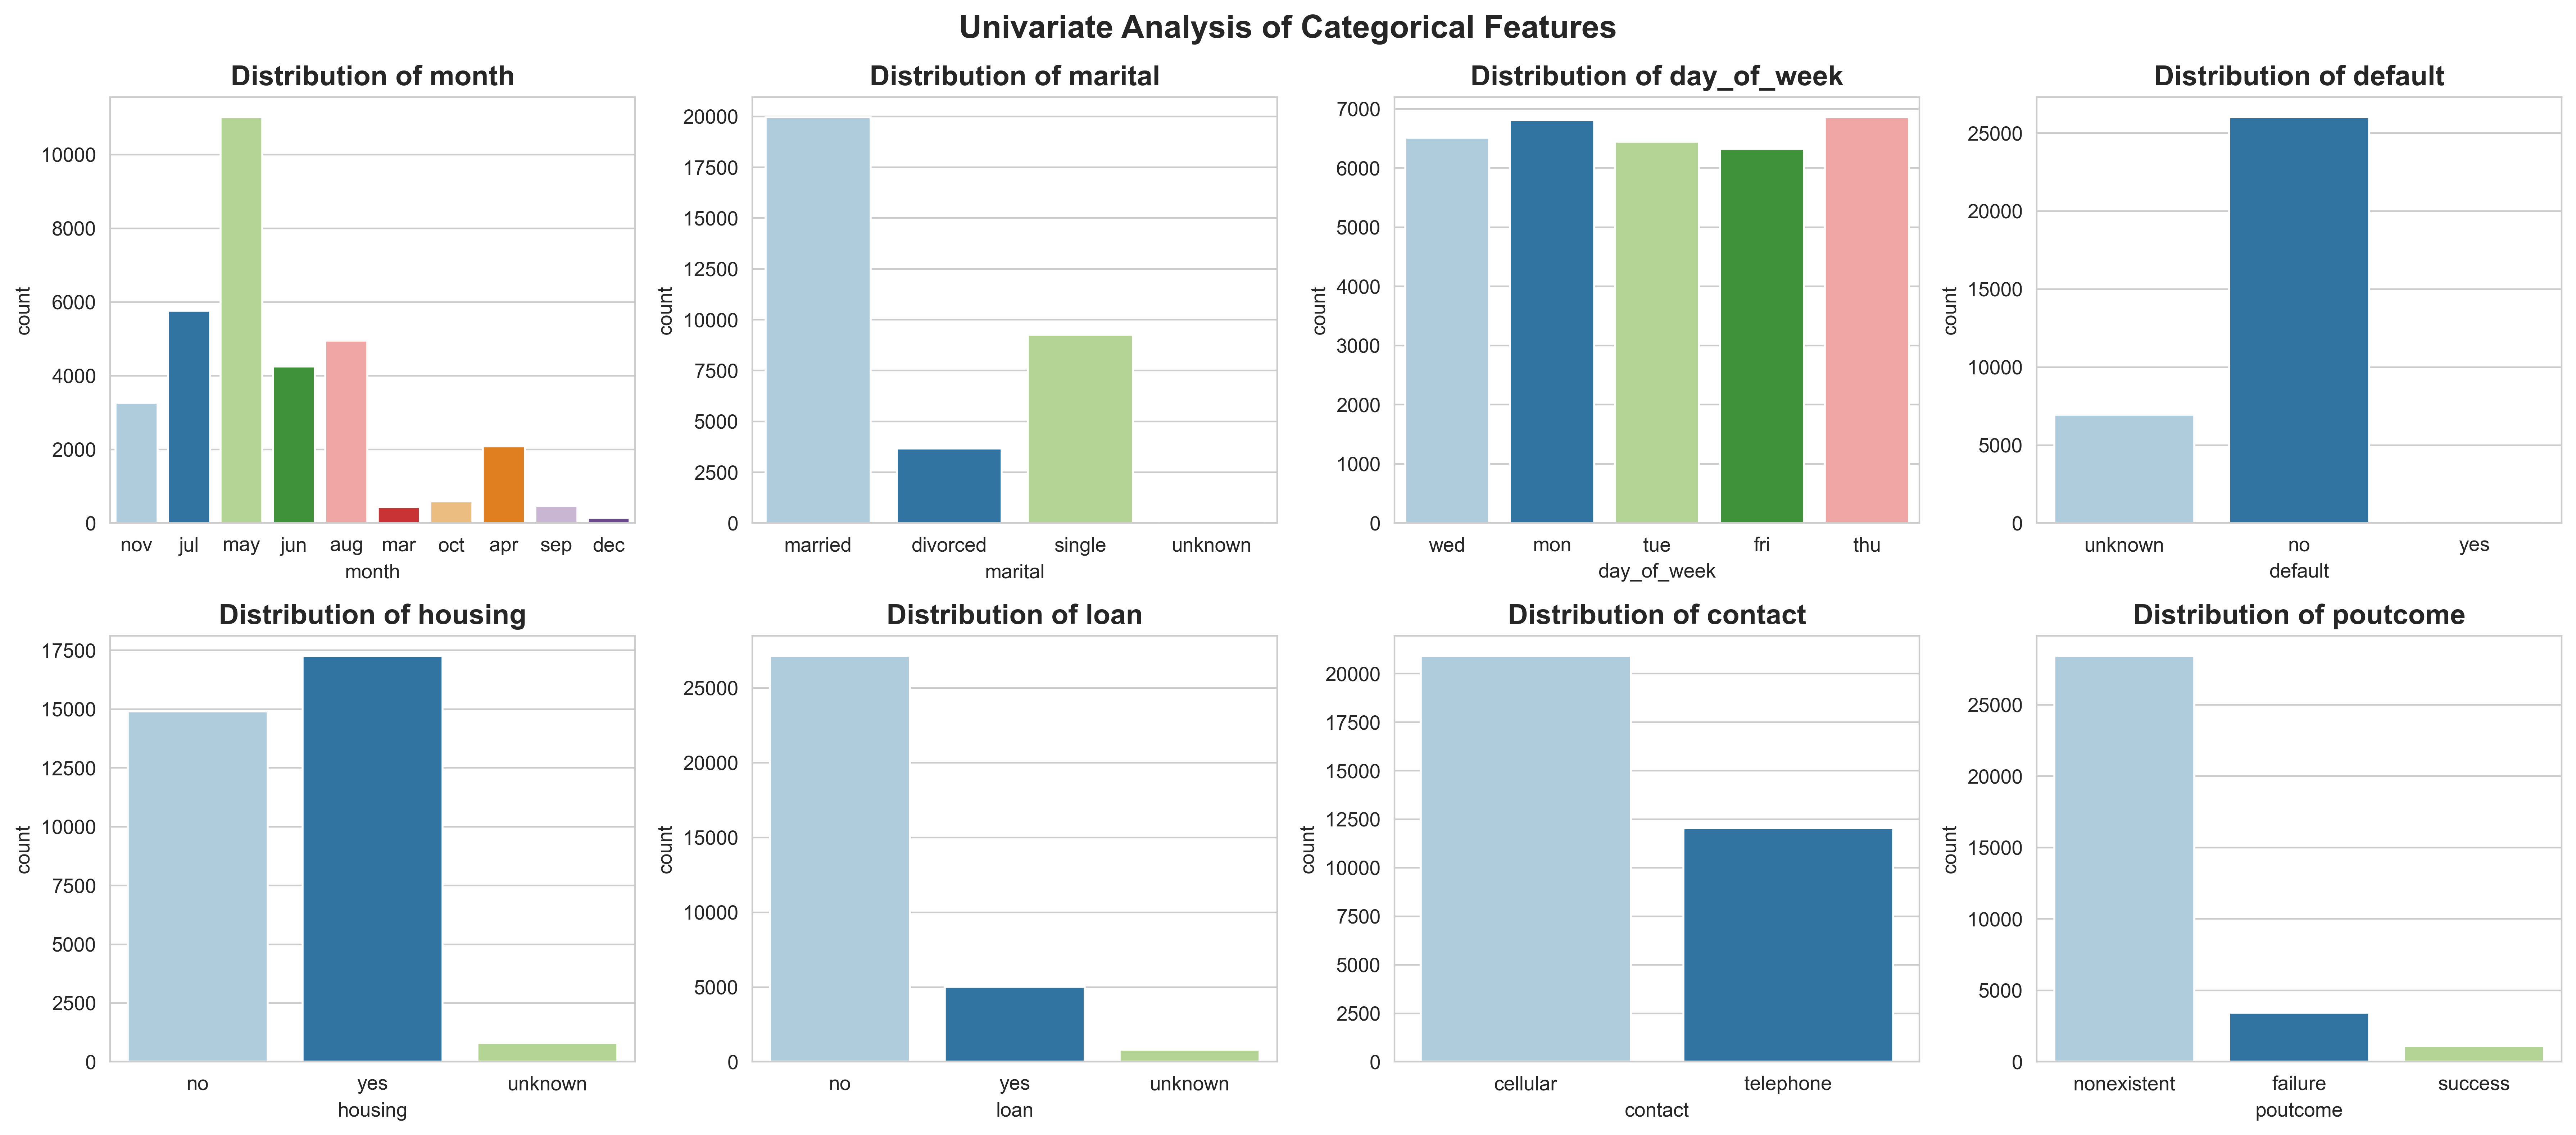

In [9]:
categorical_columns = ['month', 'marital', 'day_of_week', 'default', 'housing', 'loan', 'contact', 'poutcome']
fig, ax = plt.subplots(2,4,figsize=(18,8),dpi=400)
ax_flat = ax.flatten()
for i, col in enumerate(categorical_columns):
    sns.countplot(data=train_df, x=col, ax=ax_flat[i], hue=col, palette ='Paired')
    ax_flat[i].set_title(f"Distribution of {col}",fontsize = 14,fontweight='bold')

    if col in ['job', 'education']:
        ax_flat[i].tick_params(axis='x',rotation=45)

plt.suptitle("Univariate Analysis of Categorical Features",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Univariate Analysis — Categorical Features

### Month
- **May** dominates with 11,000+ contacts — bank ran most calls in May
- **Decision:** Keep as-is, apply One-Hot Encoding in pipeline

### Marital
- **Married** clients are the majority (~20,000)
- **Unknown** is very small — will be imputed with mode (`married`)
- **Decision:** Impute unknowns, apply One-Hot Encoding

### Day of Week
- Distribution is nearly **uniform** across all 5 working days
- No single day dominates — weak predictive signal expected
- **Decision:** Keep, apply One-Hot Encoding

### Default
- **Yes** = only very low clients out of 32,950 — near-zero variance
- **Unknown** = 6,940 (21.1%) — too many missing values to impute reliably
- **Decision:** Drop this column entirely in pipeline

### Housing
- Slightly more clients **have** a housing loan (yes > no)
- **Unknown** = 796 rows — same rows as loan unknowns (confirmed earlier)
- **Decision:** Impute with mode, apply One-Hot Encoding

### Loan
- Most clients have **no** personal loan
- **Unknown** = 796 rows — same rows as housing unknowns
- **Decision:** Impute with mode, apply One-Hot Encoding

### Contact
- **Cellular** is the dominant contact method
- **Decision:** Keep, apply One-Hot Encoding

### Poutcome
- **Nonexistent** dominates — most clients were never contacted before
- **Success** is small but highly predictive — previous success → likely to subscribe again
- **Decision:** Keep, apply One-Hot Encoding

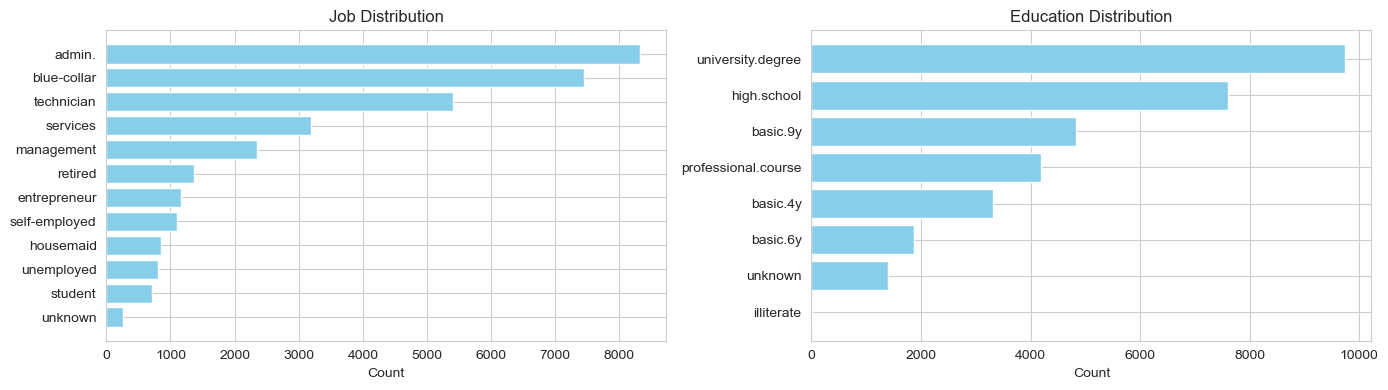

In [10]:
import matplotlib.pyplot as plt

cols = ['job', 'education']

fig, ax = plt.subplots(1, 2, figsize=(14,4))

for i, col in enumerate(cols):

    counts = train_df[col].value_counts().sort_values(ascending=True)

    ax[i].barh(counts.index, counts.values, color="skyblue")

    ax[i].set_title(f"{col.capitalize()} Distribution")
    ax[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

**Observation** :
Most customers belong to admin, blue-collar, and technician roles, indicating a working-class population with stable income, which can influence their likelihood to invest

Most customers are well-educated, especially with university degrees, indicating higher financial awareness, which can positively influence subscription decisions.

## check for Correlation beteen variables
- Are two numerical features carrying the same information?

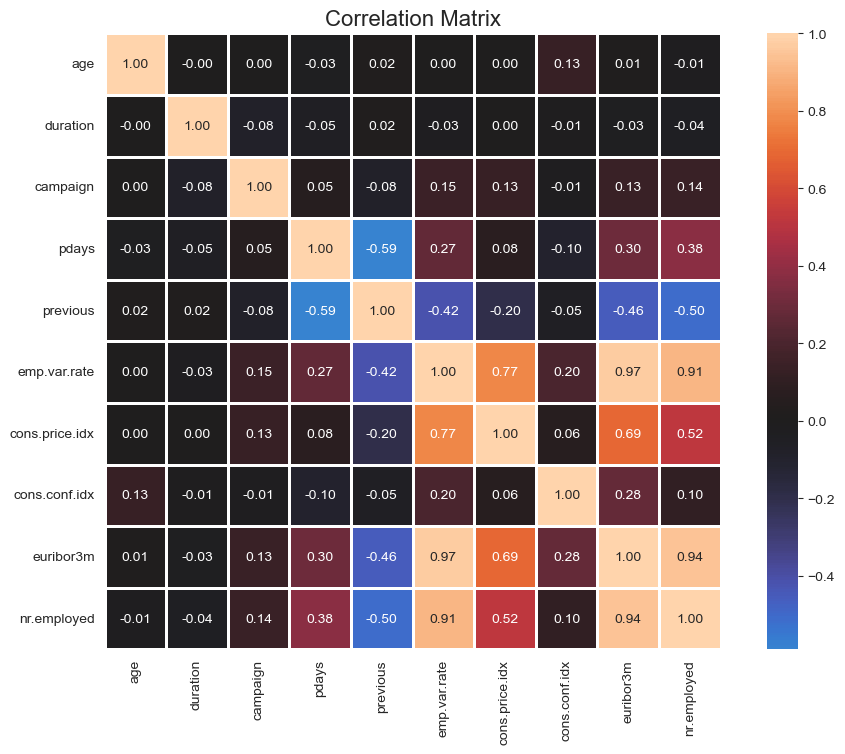

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, linewidths=1, center=0, fmt=".2f", square=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()


Several economic indicators (emp.var.rate, euribor3m, nr.employed) are highly correlated, suggesting potential redundancy. 
For certain models sensitive to multicollinearity, one or more of these variables may be removed or combined.

In pipline 
Handle Multicollinearity Economic features are highly correlated(May be apply PCA (Principal Component Analysis))

Drop duration for real-world model 

### Previous Campaign Outcome vs Subscription
| Value       | Meaning                    |
| ----------- | -------------------------- |
| success     | customer subscribed before |
| failure     | customer rejected before   |
| nonexistent | never contacted            |


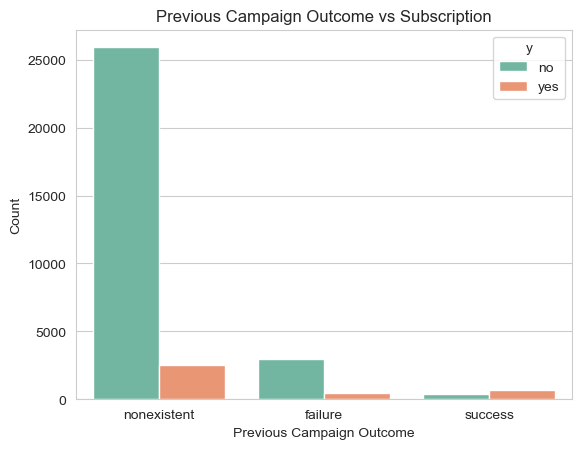

In [12]:
sns.countplot(data=train_df, x="poutcome", hue="y", palette="Set2")

plt.title("Previous Campaign Outcome vs Subscription")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Count")
plt.show()

Previous campaign success appears to positively influence the likelihood of subscription, making `poutcome` a potentially strong predictor for the target variable.

## Check Target Distribution

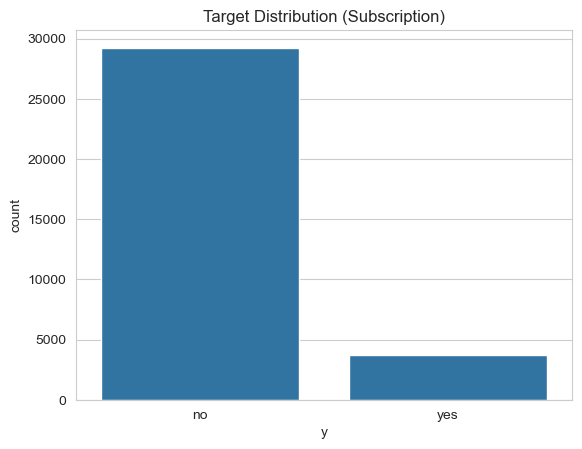

In [13]:
sns.countplot(data=train_df, x='y')
plt.title("Target Distribution (Subscription)")
plt.show()

**Observation** :
Most customers did not subscribe to the term deposit, indicating that the dataset is highly imbalanced. This suggests that predicting positive subscriptions may be more challenging for the model.


 ## Job and Marital Status vs Target

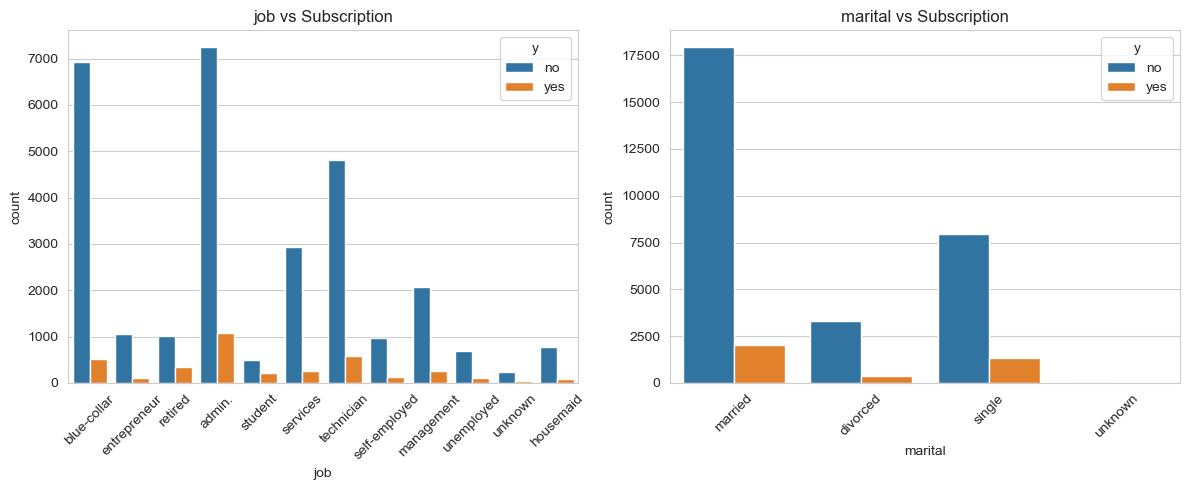

In [14]:
cols = ['job', 'marital']
plt.figure(figsize=(12, 5)) 

for i, col in enumerate(cols):
    plt.subplot(1, 2, i + 1)  
    sns.countplot(x=col, hue='y', data=train_df)  
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Subscription")

plt.tight_layout() 
plt.show()


Job vs Subscription

Observation :
Most customers work in admin., blue-collar, and technician roles, indicating that the bank mainly targets working professionals. However, across all job categories, the number of customers who did not subscribe is much higher than those who subscribed.

Marital Status vs Subscription

Observation :
The majority of customers are married, followed by single and divorced individuals. Similar to the overall trend, non-subscriptions dominate across all marital groups, suggesting marital status may have limited influence on subscription decisions.

# Going to analysis each feature one by one 

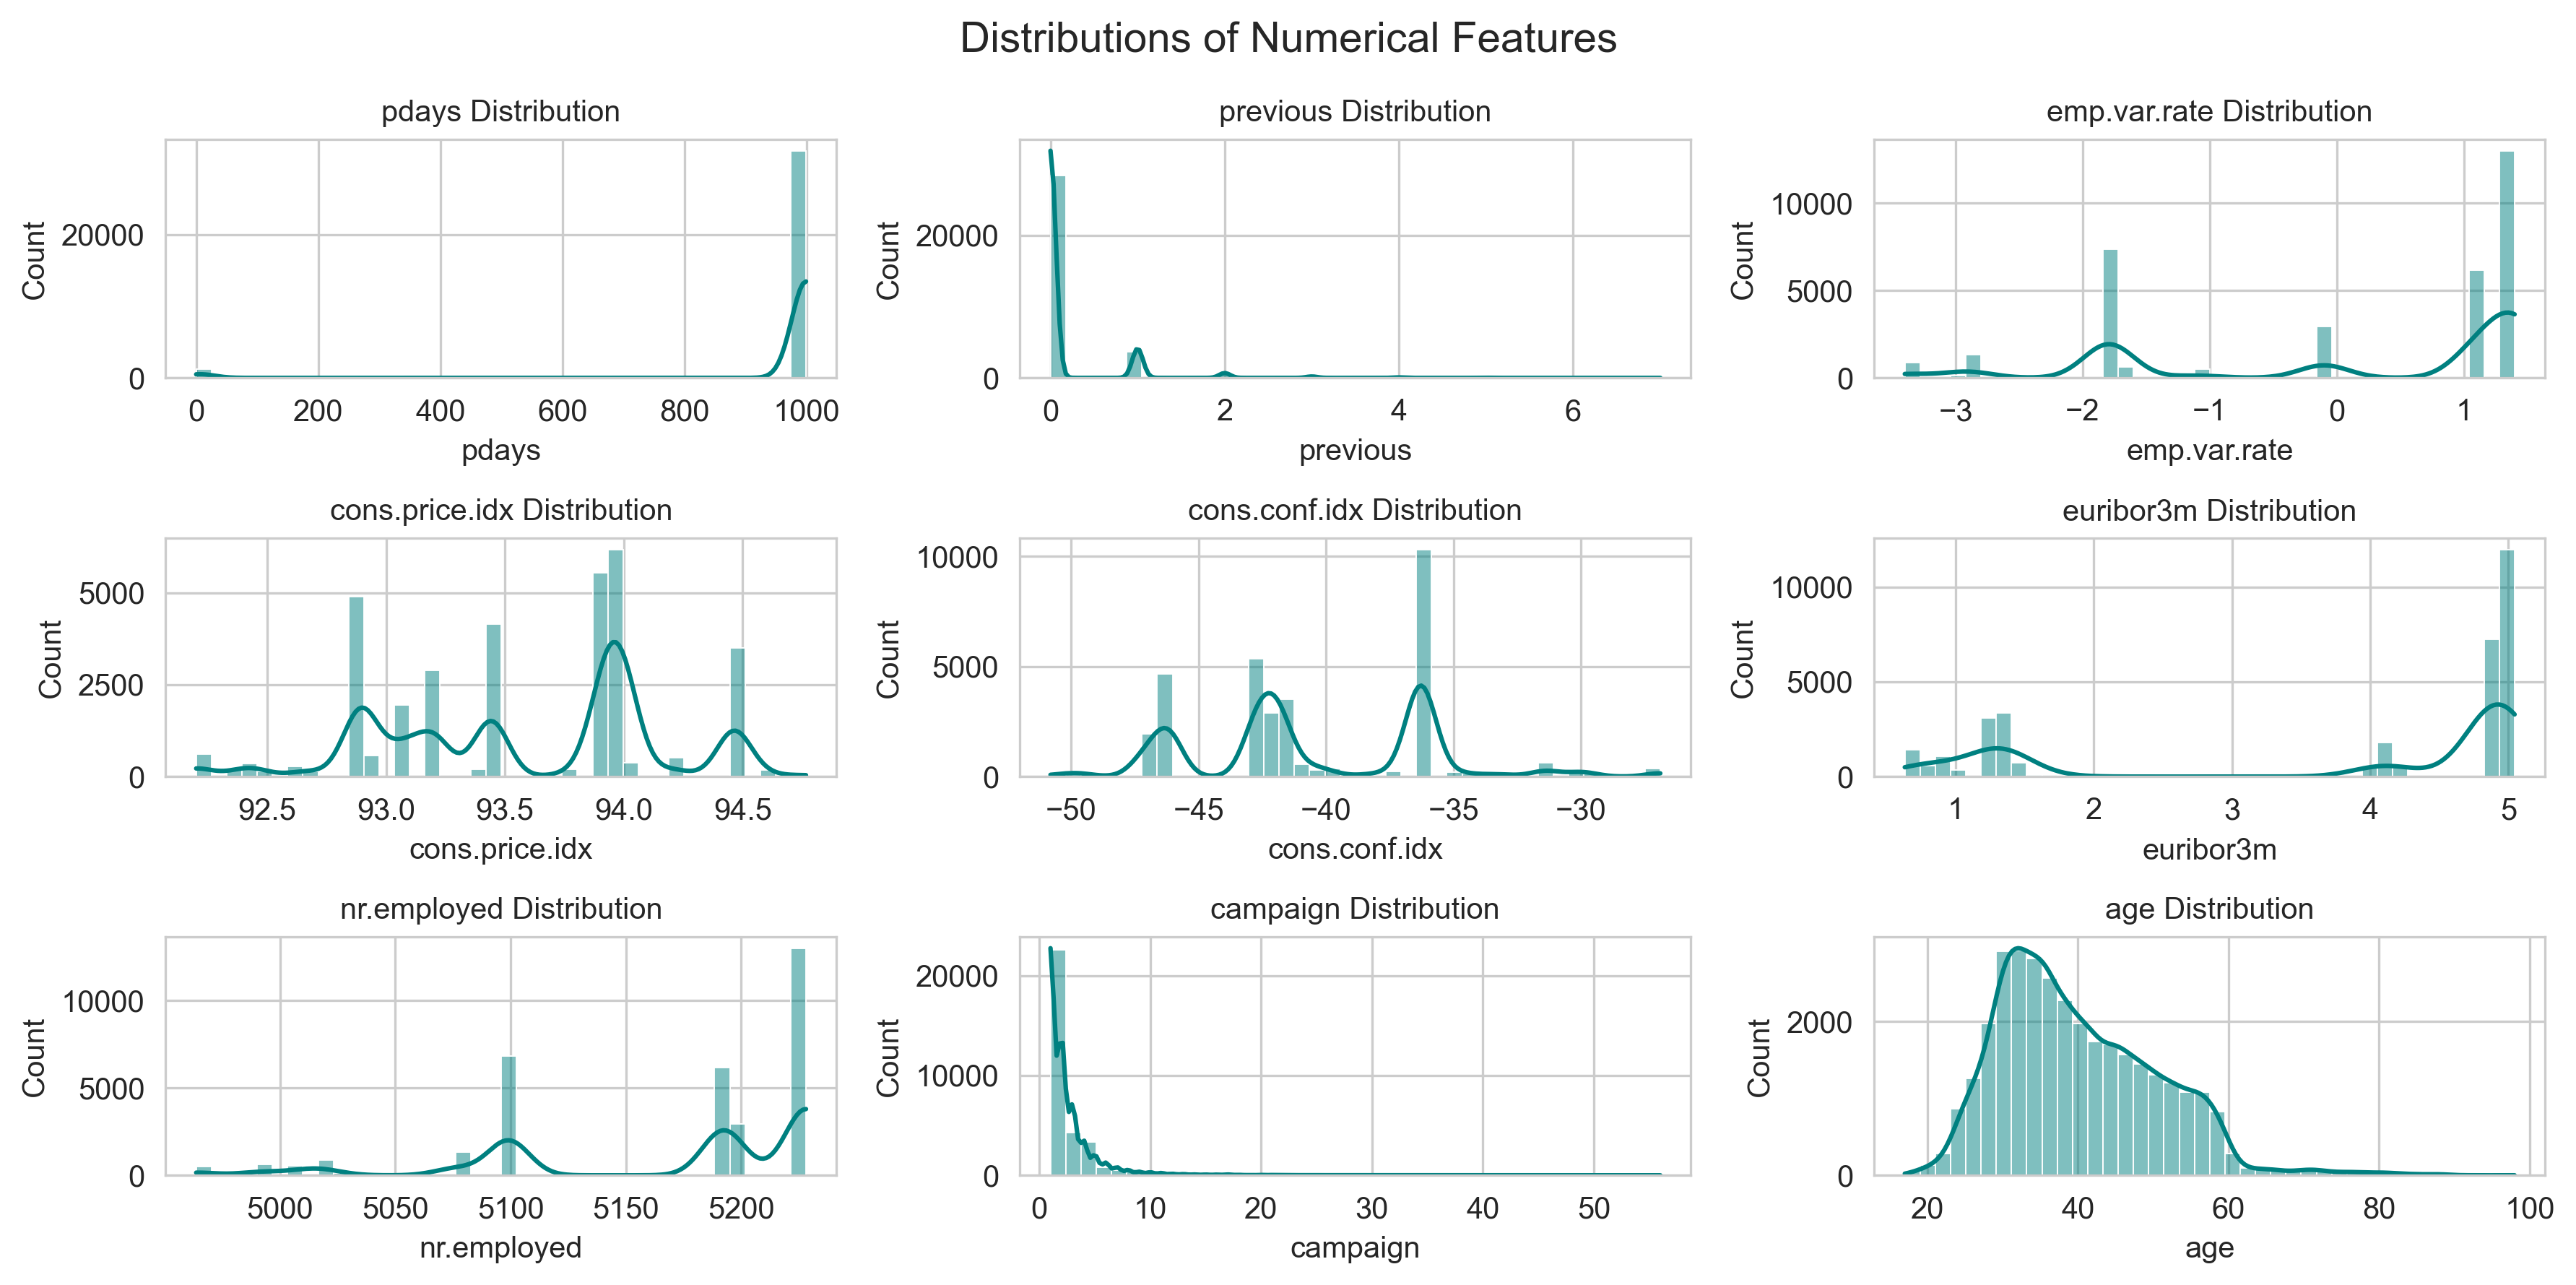

In [15]:
num_cols = ['pdays','previous','emp.var.rate','cons.price.idx',
            'cons.conf.idx','euribor3m','nr.employed','campaign','age']

fig, ax = plt.subplots(3,3, figsize=(12,6), dpi=300)
ax_flat = ax.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=train_df,
        x=col,
        bins=40,
        kde=True,
        ax=ax_flat[i],
        color='teal'
    )

    ax_flat[i].set_title(f"{col} Distribution", fontsize=10)

plt.suptitle("Distributions of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
train_df['pdays'].value_counts()

pdays
999    31724
3        355
6        337
4         97
2         52
7         47
9         45
10        43
12        40
5         40
13        28
1         22
11        21
15        21
14        18
8         14
0         12
16         9
17         8
18         6
22         3
19         2
21         2
27         1
25         1
20         1
26         1
Name: count, dtype: int64

Age – Customer ages range from 17 to 98, with most clients concentrated between 25–55 years, indicating that the campaign primarily targets the working-age population.

Campaign (Number of Contacts During Campaign) – Most customers were contacted only a few times (1–3 calls). Extremely high values (e.g., >10 contacts) are rare and may represent outliers or persistent follow-up attempts.

Pdays (Days Since Last Contact in Previous Campaign) – The value 999 dominates, meaning most clients were never contacted in previous marketing campaigns, while a small portion were contacted within 0–30 days earlier.

Previous (Number of Previous Campaign Contacts) – The distribution is highly concentrated at 0, indicating that most customers had no prior interactions with earlier campaigns.

Emp.var.rate (Employment Variation Rate) – This macroeconomic indicator reflects changes in employment levels. The clustered distribution suggests the data was collected across specific economic phases.

Cons.price.idx (Consumer Price Index) – Represents the price level of consumer goods (inflation indicator). The relatively narrow range indicates stable inflation levels during the campaign period.

Cons.conf.idx (Consumer Confidence Index) – Measures consumer sentiment about the economy. Negative values suggest moderate economic uncertainty among consumers during the campaign.

Euribor3m (3-Month Euro Interbank Offered Rate) – This interest rate indicator shows clear peaks, reflecting changes in European lending rates during the campaign timeline.

Nr.employed (Number of Employees in the Economy) – Represents the total employment level in the economy, with clustered values indicating economic stability with slight shifts over time.

<Axes: >

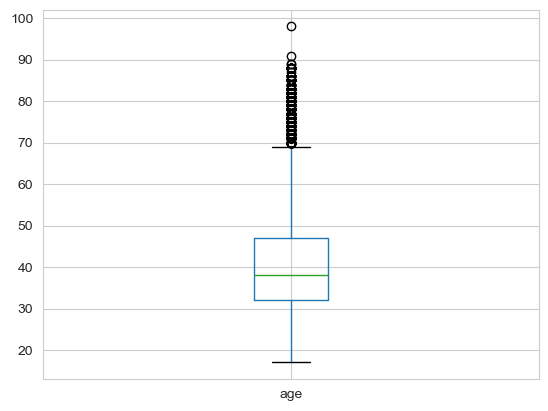

In [17]:
train_df.boxplot(column='age')


## EDA Summary & Preprocessing Decisions

### Dataset
- 41,188 rows · 20 features · Binary classification task
- All EDA performed on train_df (32,950 rows) only

### Target Variable
- Heavily imbalanced — 88.7% `no` / 11.3% `yes` (~8:1 ratio)
- Metric strategy → F1-score + ROC-AUC (not accuracy)

### Columns to Drop
| Column | Reason |
|--------|--------|
| `duration` | Data leakage — unknown before call ends |
| `default` | Near-zero variance (only 3 `yes` values) |
| `pdays` | Replaced by engineered feature |

### Feature Engineering
- `previous_contact` = 1 if pdays != 999 else 0

### Missing Values (unknowns → NaN)
| Column | Count | Strategy |
|--------|-------|----------|
| `job` | 265 | Impute mode |
| `marital` | 65 | Impute mode |
| `education` | 1,397 | Impute mode |
| `housing` | 796 | Impute mode |
| `loan` | 796 | Impute mode |

### Encoding Strategy
- One-Hot Encoding → `job`, `marital`, `contact`, `month`, 
  `day_of_week`, `poutcome`, `housing`, `loan`
- Ordinal Encoding → `education` (has natural order)

### Scaling
- StandardScaler → all numerical features

### Class Imbalance Strategy
- Use `class_weight='balanced'` in models
- Evaluate with F1-score and ROC-AUC

### Key EDA Findings
- `poutcome = success` → strongest predictor of subscription
- `euribor3m`, `emp.var.rate`, `nr.employed` are highly correlated
- `campaign` and `duration` are heavily right-skewed
- `housing` and `loan` unknowns come from the exact same 796 rows
- Cellular contact method has higher subscription rate than telephone
